# 8-Channel MTS example test
---

This notebook is based on Xilinx [RFSoC-MTS](https://github.com/Xilinx/RFSoC-MTS/blob/main/boards/ZCU208/notebooks/rfsocMTS.ipynb) and enabling all 8 ADCs and DACs.

This overlay provides one DAC player memory that is broadcast to multiple RF DAC tiles. All ADC tiles capture to internal memories.  ADC tile 225 channel 1 stores to the PL DRAM via DMA.  A simplified block diagram is presented below.

The following results were captured when looping back DAC 0 -> ADC 0, DAC 1 -> ADC 1, DAC 2 -> ADC 2, DAC 3 -> ADC 3, DAC 4 -> ADC 4, DAC 5 -> ADC 5, DAC 6 -> ADC 6, and DAC 7 -> ADC 7 (using SMA female-to-female SMA adapters and SMA DC Blocks).

### Preparation from a PYNQ 3.0.1 image:

1. Patch xrfdc to version 2.0 for enabling MTS following the [installation script](https://github.com/Xilinx/RFSoC-MTS/blob/main/install.sh).
2. Install `xrfclk` TICS files for testing frequency settings: 4.0 Gsps for DAC and ADC.
    ```
    sudo cp pynq_llrf/boards/CLK104/external_mo/*.txt* /usr/local/share/pynq-venv/lib/python3.10/site-packages/xrfclk/
    ```
3. Expect the following files in `/home/xilinx/jupyter_notebooks/RFSoC-MTS/pynq_llrf/mimo_mts`:
    * `ddr4.dtbo`: built by `pynq_llrf/boards/ZCU208/dts/Make` via device tree compiler
    * `mts_8ch_evr.bit` and `mts_8ch_evr.hwh`.

In [1]:
%cd /home/xilinx/jupyter_notebooks/RFSoC-MTS/pynq_llrf

/home/xilinx/jupyter_notebooks/RFSoC-MTS/pynq_llrf


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

from pynq import Clocks
from mimo_mts import MimoMtsOverlay

%load_ext autoreload
%autoreload 2

In [3]:
ol = MimoMtsOverlay("mts_8ch_wrapper.bit", lmk_freq=499.63, lmx_freq=3997.11)

print(f'Overlay loaded :{ol.is_loaded()}')

Addr 0x147: val = 0xa; clkin = clkin0 (ext)


Overlay loaded :True


In [4]:
print(f'CPU:   {Clocks.cpu_mhz:10.3f} MHz')
print(f'FCLK0: {Clocks.fclk0_mhz:10.3f} MHz')

CPU:     1199.988 MHz
FCLK0:     99.999 MHz


In [5]:
from mimo_mts.utils.plot import plot_adc_wfm, plot_adc_psd, plot_complex_wfm_stack

# DAC_SR = 3997.11e6
# ADC_SR = 3997.11e6
fs = 4e9

# Generate Waveforms for Loopback
 This overlay uses a single waveform memory that is broadcast to multiple DAC tiles.
### Prepare the DAC Memory
The cell below generates examples waveforms and has customizable paramters.  For example, one can adjust the center frequency, Fc, and re-generate a sinewave.

In [6]:
Fc = fs / 16 # 250 MHz
t = np.arange(ol.dac_player.size) / fs
amp =  (1 << 15) - 1
DAC_sinewave = amp * np.sin(2 * np.pi * Fc * t)

In [7]:
ol.dac_player[:] = np.int16(DAC_sinewave)

## Capture DAC Waveform to Internal Memory

The DAC waveform is saved to an internal memory for verification purposes.


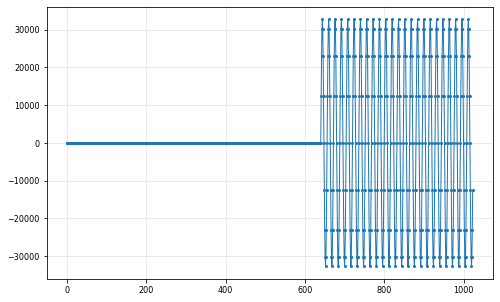

In [8]:
ol.trigger_capture()
plt.plot(ol.dac_capture[:1024], marker='o', linewidth=1, markersize=2);

In [9]:
darray_i = np.empty((ol.n_adcs, len(ol.adc_i_bufs[0])), dtype=np.int16)
darray_q = np.empty((ol.n_adcs, len(ol.adc_q_bufs[0])), dtype=np.int16)

ol.set_adc_mixer_dco(freq_mhz=0, phase=0)
ol.capture_adc_iq_buf(darray_i, darray_q);

In [10]:
start = 1165 # start of the signal
print(f'RF loop back latency: {start/fs * 1e9} ns')

RF loop back latency: 291.25 ns


XXX: observed uncertain of (2 ns) loop back latency, could be trigger edge in 500MHz clock domain

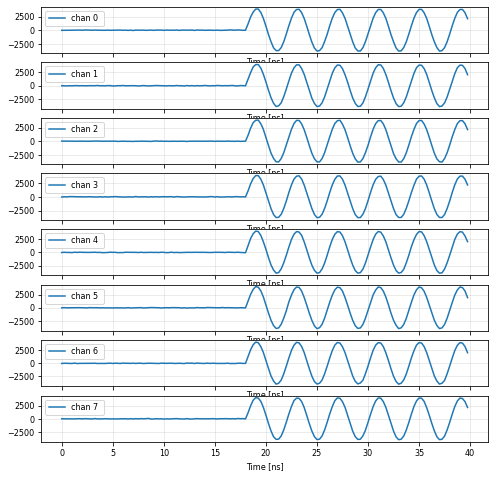

In [11]:
plot_adc_wfm(darray_i[:, start-80:start+80], fs=fs)

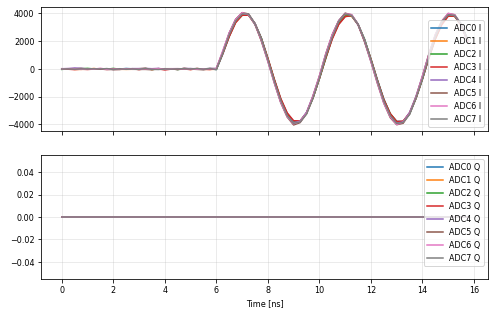

In [12]:
ol.set_adc_mixer_dco(phase=0)
ol.capture_adc_iq_buf(darray_i, darray_q);
carray = darray_i + 1j * darray_q
plot_complex_wfm_stack(carray[:, start-32:start+32], fs=fs)

### Change mixer phase to 90 deg and check I/Q waveforms

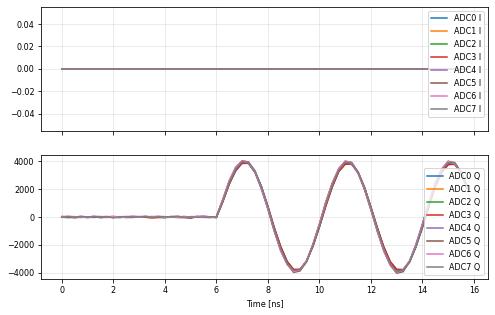

In [15]:
ol.set_adc_mixer_dco(phase=90)
ol.capture_adc_iq_buf(darray_i, darray_q);
carray = darray_i + 1j * darray_q
plot_complex_wfm_stack(carray[:, start-32:start+32], fs=fs)


### Verify Alignment Stability

In [19]:
n_samples = 1024
for i in range(3):
    ol.capture_adc_iq_buf(darray_i, darray_q);
    x = darray_q[0, start:start+n_samples].astype(np.float32)  # adc0 Q
    y = darray_q[3, start:start+n_samples].astype(np.float32)  # adc3 Q
    x_corr = np.correlate(x, y, mode='full')
    lags = np.arange(-n_samples+1, n_samples)
    delay = lags[np.argmax(x_corr)]
    print(f'Iteration {i} : Cross-correlation delay = {delay} samples')
    assert delay == 0, 'Cross-correlation delay is not zero'

Iteration 0 : Cross-correlation delay = 0 samples
Iteration 1 : Cross-correlation delay = 0 samples
Iteration 2 : Cross-correlation delay = 0 samples


### Test deterministic latency incurred due to alignment
Every reboot should result in the same latency and offet \
Example: \
DAC Latency: 136, Offset: 16 \
ADC Latency:  96, Offset: 8

In [20]:
for i in range(4):
    print(f"DAC Tile {i} Latency: {ol.xrfdc.mts_dac_config.Latency[i]:3d}, Offset: {ol.xrfdc.mts_dac_config.Offset[i]}")
    print(f"ADC Tile {i} Latency: {ol.xrfdc.mts_adc_config.Latency[i]:3d}, Offset: {ol.xrfdc.mts_adc_config.Offset[i]}")

DAC Tile 0 Latency: 136, Offset: 16
ADC Tile 0 Latency:  96, Offset: 8
DAC Tile 1 Latency: 136, Offset: 16
ADC Tile 1 Latency:  96, Offset: 8
DAC Tile 2 Latency: 136, Offset: 16
ADC Tile 2 Latency:  96, Offset: 8
DAC Tile 3 Latency: 136, Offset: 16
ADC Tile 3 Latency:  96, Offset: 8


### Set DAC baseband waveform as DC, reset mixer

In [21]:
n_samples = ol.dac_player.size
ol.dac_player[:] = np.ones(n_samples, dtype=np.int16) * 32767
ol.set_dac_mixer_dco(0)
ol.set_adc_mixer_dco(0)

In [22]:
ol.dac_player[-32:] = 0  # XXX hack

### Change DAC mixer setting with NCO to 125 MHz

In [23]:
ol.set_dac_mixer_dco(125)

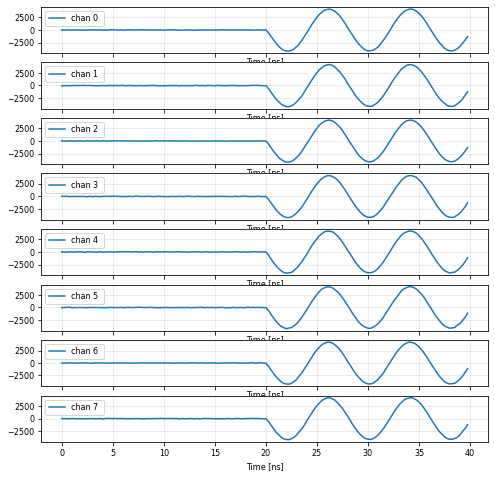

In [24]:
ol.capture_adc_iq_buf(darray_i, darray_q);
plot_adc_wfm(darray_i[:, start-80:start+80], fs=fs)

###  Change DAC mixer setting with NCO to 500 MHz

In [25]:
ol.set_dac_mixer_dco(500)

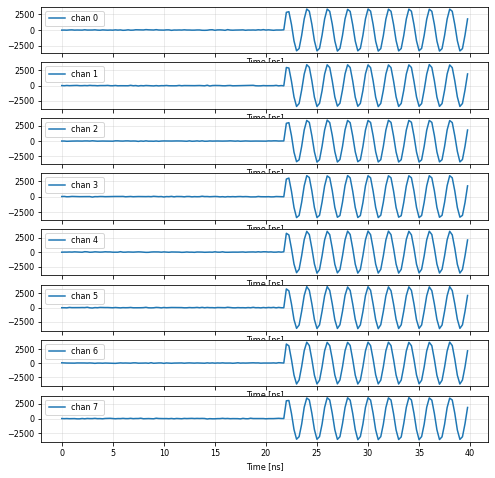

In [26]:
ol.capture_adc_iq_buf(darray_i, darray_q);
plot_adc_wfm(darray_i[:, start-80:start+80])